In [ ]:
import numpy as np 
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

In [86]:
print("=" * 60)
print("IRIS AI CLASSIFIER")
print("Project 2 - DecodeLabs")
print("=" * 60)

IRIS AI CLASSIFIER
Project 2 - DecodeLabs


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [88]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [89]:
print(df.shape)

(150, 5)


In [90]:
print("\nDataset Info")
print(df.info())

print("\nStatistics")
print(df.describe())

print("\nClass Distribution")
print(df["species"].value_counts())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistics
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000

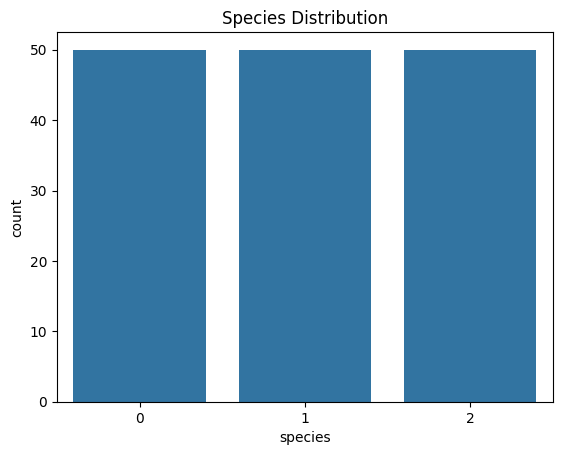

In [91]:
sns.countplot(
    x=df["species"]
)

plt.title("Species Distribution")
plt.show()

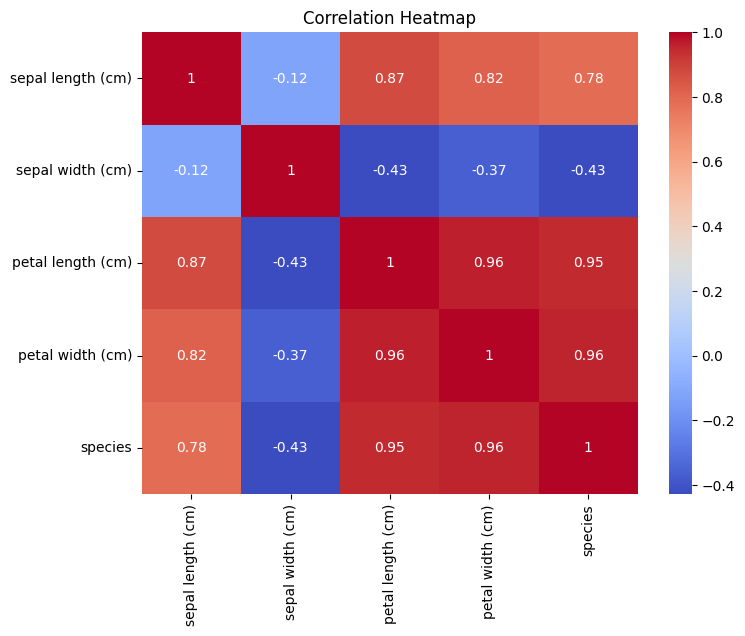

In [92]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [93]:
X = iris.data
y = iris.target

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [95]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [96]:
k_values = []
accuracies = []

for k in range(1,16):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    k_values.append(k)
    accuracies.append(acc)

    print(
        f"K={k} Accuracy={acc:.4f}"
    )

K=1 Accuracy=1.0000
K=2 Accuracy=1.0000
K=3 Accuracy=1.0000
K=4 Accuracy=1.0000
K=5 Accuracy=1.0000
K=6 Accuracy=1.0000
K=7 Accuracy=1.0000
K=8 Accuracy=1.0000
K=9 Accuracy=1.0000
K=10 Accuracy=1.0000
K=11 Accuracy=1.0000
K=12 Accuracy=1.0000
K=13 Accuracy=1.0000
K=14 Accuracy=1.0000
K=15 Accuracy=1.0000


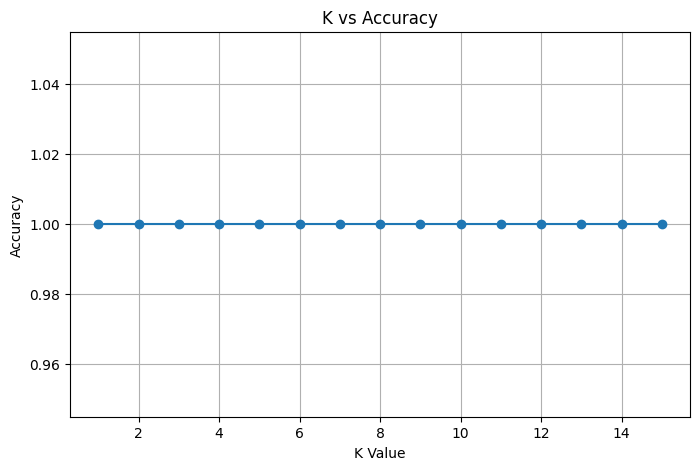

In [97]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")

plt.grid()

plt.show()

In [98]:
best_k = k_values[
    accuracies.index(
        max(accuracies)
    )
]

print(
    "Best K =",
    best_k
)

Best K = 1


In [99]:
model = KNeighborsClassifier(
    n_neighbors=best_k
)

model.fit(
    X_train,
    y_train
)

KNeighborsClassifier(n_neighbors=1)

In [100]:
y_pred = model.predict(
    X_test
)

In [101]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy = {accuracy:.4f}"
)

Accuracy = 1.0000


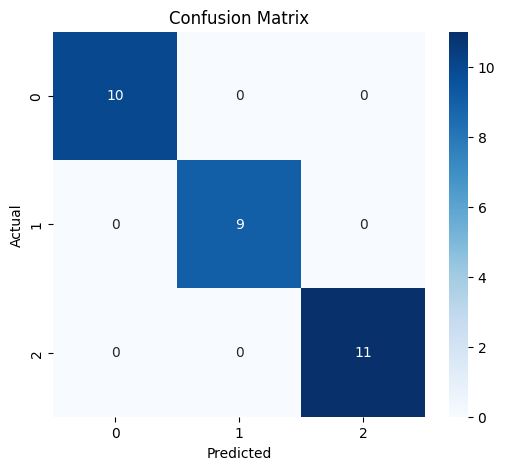

In [102]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [103]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)
print(
    f"Accuracy = {accuracy:.4f}"
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Accuracy = 1.0000


In [104]:
print(
    "\nFlower Prediction System"
)

sl = float(
    input(
        "Sepal Length: "
    )
)

sw = float(
    input(
        "Sepal Width: "
    )
)

pl = float(
    input(
        "Petal Length: "
    )
)

pw = float(
    input(
        "Petal Width: "
    )
)

sample = scaler.transform(
    [[sl, sw, pl, pw]]
)

prediction = model.predict(
    sample
)

print(
    "\nPredicted Species:",
    iris.target_names[
        prediction[0]
    ]
)


Flower Prediction System


Sepal Length:  5.5
Sepal Width:  3.5
Petal Length:  1.4
Petal Width:  0.2



Predicted Species: setosa


In [105]:
print("\nPrediction Confidence:")

probabilities = model.predict_proba(sample)[0]

for species, prob in zip(
    iris.target_names,
    probabilities
):
    print(
        f"{species}: {prob:.2%}"
    )


Prediction Confidence:
setosa: 100.00%
versicolor: 0.00%
virginica: 0.00%
